In [1]:
from cfg_tools import load_config_files

from numb_project.gw_model import MyGlobalWorkspace, get_global_workspace_mods
from numb_project.data_module import MnistDataModule
from numb_project.utils import get_domains_config

config = load_config_files(
    f"/home/lucas/gwnumb/config",
    use_cli=False,
    load_files=["config.yaml"])[0]

domain_configs = get_domains_config(['image', 'digit'])

gw_mod, selection_mod, loss_mod = get_global_workspace_mods(config, domain_configs)

gw = MyGlobalWorkspace.load_from_checkpoint(
    "/home/lucas/gwnumb/checkpoints/numb/test.ckpt",
    gw_mod=gw_mod,
    selection_mod=selection_mod,
    loss_mod=loss_mod
    )

data_module = MnistDataModule(50)

mu (latent VAE) shape: torch.Size([50, 12])
gw_latent (global workspace) shape: torch.Size([50, 10])
mu_reconstructed shape: torch.Size([50, 12])
reconstructed shape: torch.Size([50, 1, 28, 28])
MSE pipeline complet (image -> GW -> image): 0.012510
MSE reconstruction directe (image -> VAE seul): 0.007499
MSE round-trip latent (mu vs mu_reconstructed): 0.046127


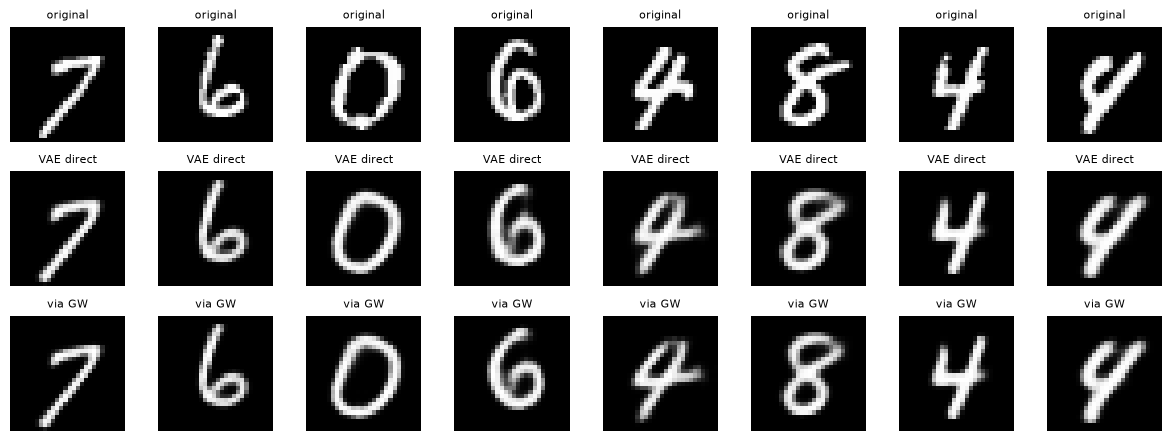

In [ ]:
import matplotlib.pyplot as plt
import torch

data_loader = data_module.test_dataloader()
mnist_vae = gw.gw_mod.domain_mods.image.vae
image_encoder = gw.gw_mod.gw_encoders.image
image_decoder = gw.gw_mod.gw_decoders.image

mnist_vae.eval()
image_encoder.eval()
image_decoder.eval()

# Récupère un batch depuis le CombinedLoader
batch, batch_idx, dataloader_idx = next(iter(data_loader))

image_batch = None
for key, value in batch.items():
    if "image" in value:
        image_batch = value["image"]
        break

if image_batch is None:
    raise ValueError("Aucune clé du batch ne contient 'image'")

device = next(mnist_vae.parameters()).device
image_batch = image_batch.to(device)

with torch.no_grad():
    # 1. Image -> espace latent VAE (mu, 12D)
    mu, logvar = mnist_vae.encoder(image_batch)
    print("mu (latent VAE) shape:", mu.shape)

    # 2. Espace latent VAE -> espace global workspace
    gw_latent = image_encoder(mu)
    print("gw_latent (global workspace) shape:", gw_latent.shape)

    # 3. Espace global workspace -> espace latent VAE (retour)
    mu_reconstructed = image_decoder(gw_latent)
    print("mu_reconstructed shape:", mu_reconstructed.shape)

    # 4. Espace latent VAE -> image reconstruite
    reconstructed = mnist_vae.decoder(mu_reconstructed)
    print("reconstructed shape:", reconstructed.shape)

    # Reconstruction "directe" (sans passer par le GW) pour comparaison
    direct_reconstructed = mnist_vae.decoder(mu)

# Erreurs
mse_full_pipeline = torch.nn.functional.mse_loss(reconstructed, image_batch)
mse_direct = torch.nn.functional.mse_loss(direct_reconstructed, image_batch)
mse_latent_roundtrip = torch.nn.functional.mse_loss(mu_reconstructed, mu)

print(f"MSE pipeline complet (image -> GW -> image): {mse_full_pipeline.item():.6f}")
print(f"MSE reconstruction directe (image -> VAE seul): {mse_direct.item():.6f}")
print(f"MSE round-trip latent (mu vs mu_reconstructed): {mse_latent_roundtrip.item():.6f}")

# Visualisation : original vs reconstruction directe vs reconstruction via GW
n_show = min(8, image_batch.shape[0])
fig, axes = plt.subplots(3, n_show, figsize=(n_show * 1.5, 4.5))

for i in range(n_show):
    axes[0, i].imshow(image_batch[i, 0].cpu().numpy(), cmap="gray")
    axes[0, i].axis("off")
    axes[0, i].set_title("original", fontsize=8)

    axes[1, i].imshow(direct_reconstructed[i, 0].cpu().numpy(), cmap="gray")
    axes[1, i].axis("off")
    axes[1, i].set_title("VAE direct", fontsize=8)

    axes[2, i].imshow(reconstructed[i, 0].cpu().numpy(), cmap="gray")
    axes[2, i].axis("off")
    axes[2, i].set_title("via GW", fontsize=8)

plt.tight_layout()
plt.show()

=== digit -> image ===
image_from_digit shape: torch.Size([50, 1, 28, 28])

=== image -> digit ===
digit_pred shape: torch.Size([50, 10])
Accuracy (image -> digit prédit): 100.00%


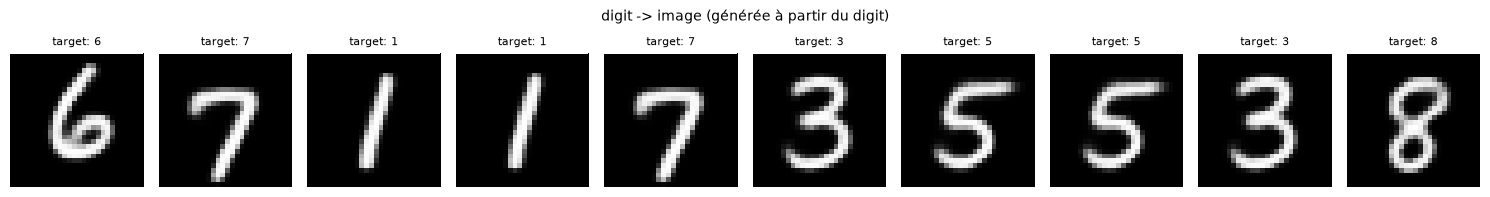

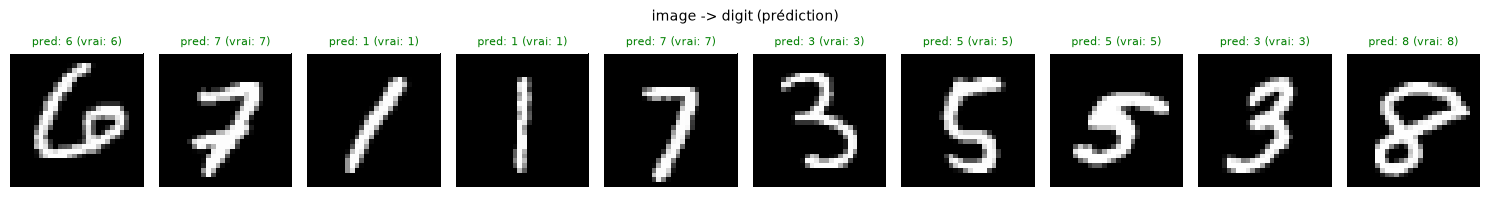

In [3]:
import matplotlib.pyplot as plt
import torch

train_loader = data_module.train_dataloader()
mnist_vae = gw.gw_mod.domain_mods.image.vae
image_encoder = gw.gw_mod.gw_encoders.image
image_decoder = gw.gw_mod.gw_decoders.image
digit_encoder = gw.gw_mod.gw_encoders.digit
digit_decoder = gw.gw_mod.gw_decoders.digit

mnist_vae.eval()
image_encoder.eval()
image_decoder.eval()
digit_encoder.eval()
digit_decoder.eval()

# Récupère un batch avec image ET digit (le domaine combiné)
batch, batch_idx, dataloader_idx = next(iter(train_loader))

image_batch, digit_batch = None, None
for key, value in batch.items():
    if "image" in value and "digit" in value:
        image_batch = value["image"]
        digit_batch = value["digit"]
        break

if image_batch is None:
    raise ValueError("Aucune clé du batch ne contient à la fois 'image' et 'digit'")

device = next(mnist_vae.parameters()).device
image_batch = image_batch.to(device)
digit_batch = digit_batch.to(device)

with torch.no_grad():
    # ---- Direction 1 : digit -> image ----
    # digit (one-hot 10D) -> espace GW
    gw_latent_from_digit = digit_encoder(digit_batch)
    # espace GW -> espace latent VAE (12D)
    mu_from_digit = image_decoder(gw_latent_from_digit)
    # espace latent VAE -> image
    image_from_digit = mnist_vae.decoder(mu_from_digit)

    # ---- Direction 2 : image -> digit ----
    # image -> espace latent VAE (12D)
    mu_from_image, _ = mnist_vae.encoder(image_batch)
    # espace latent VAE -> espace GW
    gw_latent_from_image = image_encoder(mu_from_image)
    # espace GW -> digit (one-hot 10D)
    digit_pred = digit_decoder(gw_latent_from_image)

# ---- Évaluation : digit -> image ----
true_digits = digit_batch.argmax(dim=1)
print("=== digit -> image ===")
print("image_from_digit shape:", image_from_digit.shape)

# ---- Évaluation : image -> digit ----
predicted_digits = digit_pred.argmax(dim=1)
accuracy = (predicted_digits == true_digits).float().mean()
print("\n=== image -> digit ===")
print("digit_pred shape:", digit_pred.shape)
print(f"Accuracy (image -> digit prédit): {accuracy.item():.2%}")

# ---- Visualisation : digit -> image ----
n_show = min(10, image_batch.shape[0])
fig, axes = plt.subplots(1, n_show, figsize=(n_show * 1.5, 2))
fig.suptitle("digit -> image (générée à partir du digit)", fontsize=10)

for i in range(n_show):
    axes[i].imshow(image_from_digit[i, 0].cpu().numpy(), cmap="gray")
    axes[i].axis("off")
    axes[i].set_title(f"target: {true_digits[i].item()}", fontsize=8)

plt.tight_layout()
plt.show()

# ---- Visualisation : image -> digit ----
fig, axes = plt.subplots(1, n_show, figsize=(n_show * 1.5, 2))
fig.suptitle("image -> digit (prédiction)", fontsize=10)

for i in range(n_show):
    color = "green" if predicted_digits[i] == true_digits[i] else "red"
    axes[i].imshow(image_batch[i, 0].cpu().numpy(), cmap="gray")
    axes[i].axis("off")
    axes[i].set_title(
        f"pred: {predicted_digits[i].item()} (vrai: {true_digits[i].item()})",
        fontsize=8,
        color=color,
    )

plt.tight_layout()
plt.show()


pixel_space: (2000, 784)
vision_domain_space: (2000, 12)
gw_space: (2000, 10)


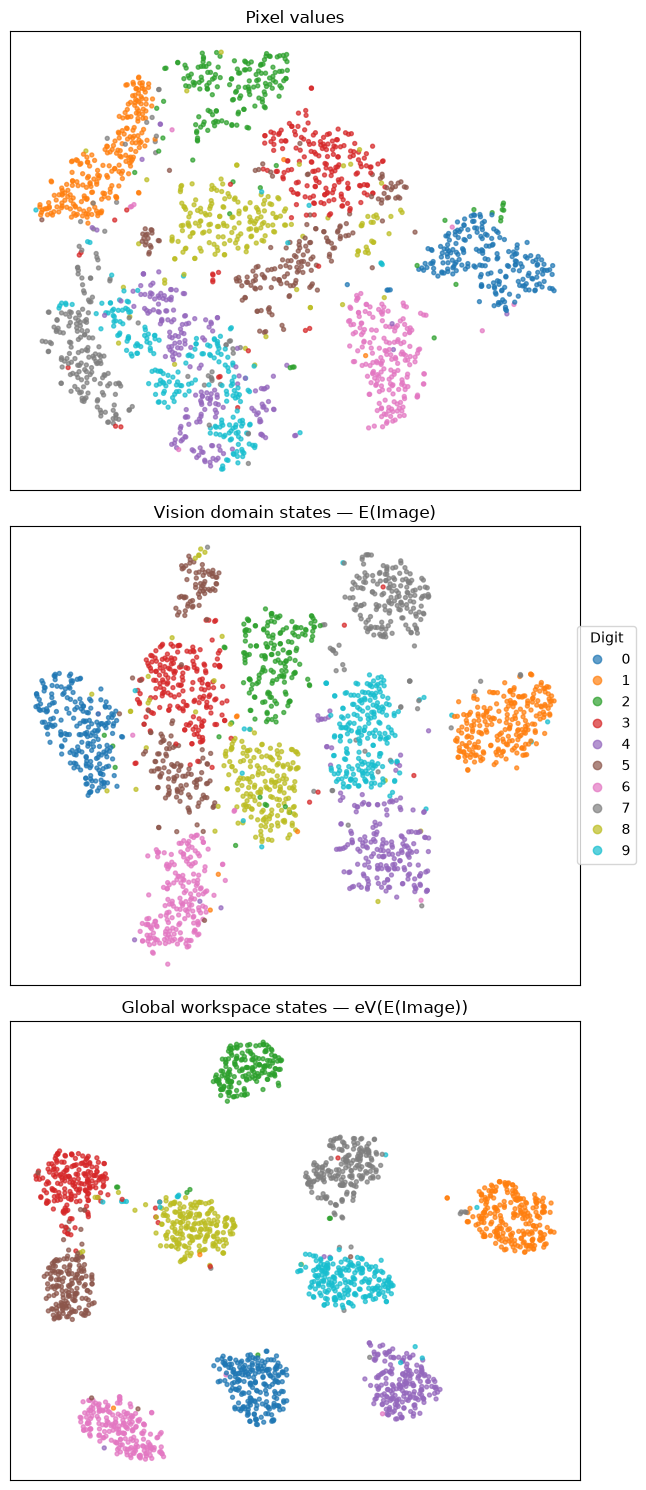

In [4]:
import matplotlib.pyplot as plt
import numpy as np
import torch
from sklearn.manifold import TSNE

mnist_vae = gw.gw_mod.domain_mods.image.vae
image_encoder = gw.gw_mod.gw_encoders.image

mnist_vae.eval()
image_encoder.eval()

# --- 1. Récupérer un échantillon suffisant du dataset (pas juste un batch) ---
N_SAMPLES = 2000  # t-SNE devient lent au-delà de quelques milliers de points

mnist_test = data_module.mnist_test  # dataset torchvision brut (image, label)
indices = np.random.choice(len(mnist_test), N_SAMPLES, replace=False)

images = torch.stack([mnist_test[i][0] for i in indices])  # (N, 1, 28, 28)
labels = np.array([mnist_test[i][1] for i in indices])     # (N,)

device = next(mnist_vae.parameters()).device
images = images.to(device)

# --- 2. Calculer les 3 représentations ---
with torch.no_grad():
    # (a) pixels bruts, aplatis
    pixel_space = images.view(images.shape[0], -1).cpu().numpy()  # (N, 784)

    # (b) états du domaine vision : sortie de l'encoder VAE (E(Image))
    mu, _ = mnist_vae.encoder(images)
    vision_domain_space = mu.cpu().numpy()  # (N, 12)

    # (c) états du global workspace : eV(E(Image))
    gw_latent = image_encoder(mu)
    gw_space = gw_latent.cpu().numpy()  # (N, gw_dim)

print("pixel_space:", pixel_space.shape)
print("vision_domain_space:", vision_domain_space.shape)
print("gw_space:", gw_space.shape)

# --- 3. t-SNE sur chacun des 3 espaces ---
def compute_tsne(X, seed=42):
    tsne = TSNE(
        n_components=2,
        perplexity=30,
        init="pca",
        random_state=seed,
    )
    return tsne.fit_transform(X)

tsne_pixel = compute_tsne(pixel_space)
tsne_vision = compute_tsne(vision_domain_space)
tsne_gw = compute_tsne(gw_space)

# --- 4. Visualisation : 3 panneaux empilés, colorés par digit ---
fig, axes = plt.subplots(3, 1, figsize=(6, 15))
titles = [
    "Pixel values",
    "Vision domain states — E(Image)",
    "Global workspace states — eV(E(Image))",
]
tsne_results = [tsne_pixel, tsne_vision, tsne_gw]

for ax, tsne_res, title in zip(axes, tsne_results, titles):
    scatter = ax.scatter(
        tsne_res[:, 0],
        tsne_res[:, 1],
        c=labels,
        cmap="tab10",
        s=8,
        alpha=0.7,
    )
    ax.set_title(title, fontsize=12)
    ax.set_xticks([])
    ax.set_yticks([])

# Légende commune (une seule, à droite)
handles, _ = scatter.legend_elements()
fig.legend(
    handles,
    [str(i) for i in range(10)],
    loc="center right",
    bbox_to_anchor=(1.08, 0.5),
    title="Digit",
)

plt.tight_layout()
plt.show()